In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from hmmlearn.hmm import GaussianHMM
import warnings
warnings.filterwarnings('ignore')

# Cargar features
daily = pd.read_csv("../data/processed/eurusd_features.csv", 
                    index_col=0, parse_dates=True)

print(f"Datos cargados: {daily.shape}")
print(f"Período: {daily.index[0].date()} → {daily.index[-1].date()}")

Datos cargados: (4031, 37)
Período: 2010-10-08 → 2026-04-03


In [2]:
# Features que usará el HMM para detectar regímenes
# Usamos retornos, volatilidad y ATR — capturan bien el estado del mercado
features_hmm = daily[['returns', 'volatility_20', 'atr_14', 'rsi_14']].copy()

# Normalizar
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X = scaler.fit_transform(features_hmm)

print(f"Shape de entrada al HMM: {X.shape}")
print("Features usados:", features_hmm.columns.tolist())

# Entrenar HMM con 3 estados
np.random.seed(42)
hmm = GaussianHMM(
    n_components=3,      # 3 regímenes: bajista, ranging, alcista
    covariance_type="full",
    n_iter=1000,
    random_state=42
)
hmm.fit(X)

print(f"\nModelo entrenado.")
print(f"Convergió: {hmm.monitor_.converged}")
print(f"Log-likelihood: {hmm.score(X):.2f}")

Shape de entrada al HMM: (4031, 4)
Features usados: ['returns', 'volatility_20', 'atr_14', 'rsi_14']

Modelo entrenado.
Convergió: True
Log-likelihood: -14742.56


In [3]:
# Decodificar la secuencia de regímenes
estados = hmm.predict(X)
daily['regime'] = estados

# Identificar qué estado corresponde a qué régimen
# basándonos en la volatilidad promedio de cada estado
vol_por_estado = daily.groupby('regime')['volatility_20'].mean()
print("Volatilidad promedio por estado:")
print(vol_por_estado.round(4))

retorno_por_estado = daily.groupby('regime')['returns'].mean()
print("\nRetorno medio por estado:")
print(retorno_por_estado.round(6))

print("\nDistribución de estados:")
print(daily['regime'].value_counts().sort_index())

Volatilidad promedio por estado:
regime
0    0.0551
1    0.0841
2    0.1280
Name: volatility_20, dtype: float64

Retorno medio por estado:
regime
0   -0.000046
1   -0.000008
2   -0.000133
Name: returns, dtype: float64

Distribución de estados:
regime
0    1832
1    1518
2     681
Name: count, dtype: int64


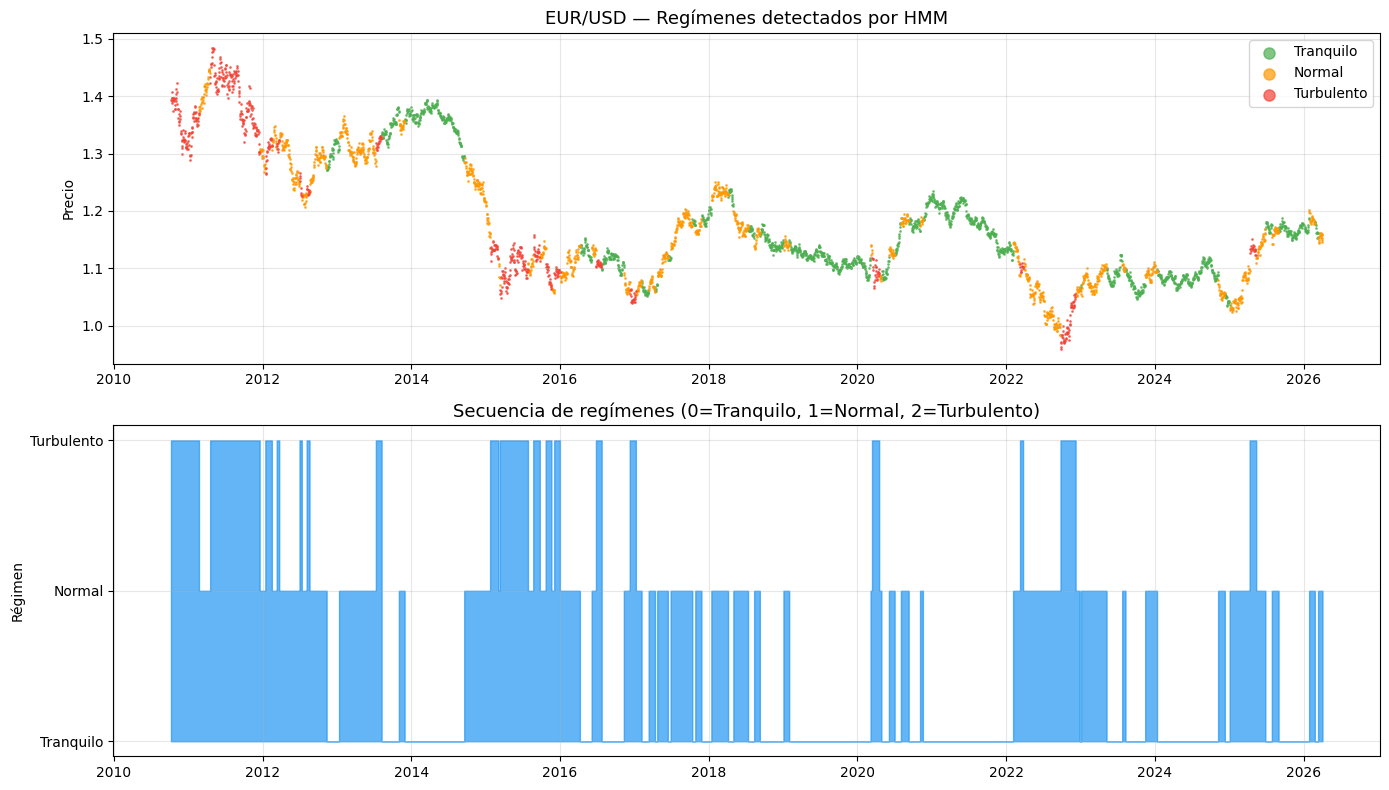

In [4]:
# Colores por régimen
colores = {0: '#4CAF50', 1: '#FF9800', 2: '#F44336'}
nombres = {0: 'Tranquilo', 1: 'Normal', 2: 'Turbulento'}

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Precio coloreado por régimen
for estado in [0, 1, 2]:
    mask = daily['regime'] == estado
    axes[0].scatter(daily.index[mask], daily['Close'][mask], 
                   c=colores[estado], s=1, label=nombres[estado], alpha=0.7)

axes[0].set_title('EUR/USD — Regímenes detectados por HMM', fontsize=13)
axes[0].set_ylabel('Precio')
axes[0].legend(markerscale=8, fontsize=10)
axes[0].grid(True, alpha=0.3)

# Régimen en el tiempo
axes[1].fill_between(daily.index, daily['regime'], 
                     step='mid', alpha=0.7,
                     color='#2196F3')
axes[1].set_title('Secuencia de regímenes (0=Tranquilo, 1=Normal, 2=Turbulento)', fontsize=13)
axes[1].set_ylabel('Régimen')
axes[1].set_yticks([0, 1, 2])
axes[1].set_yticklabels(['Tranquilo', 'Normal', 'Turbulento'])
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../data/processed/05_regimenes_hmm.png', dpi=150)
plt.show()

In [5]:
import pickle

# Guardar modelo HMM
with open("../data/processed/hmm_model.pkl", "wb") as f:
    pickle.dump(hmm, f)

# Guardar scaler
with open("../data/processed/hmm_scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

# Guardar datos con régimen
daily.to_csv("../data/processed/eurusd_con_regimen.csv")

print("Guardado:")
print("  hmm_model.pkl")
print("  hmm_scaler.pkl")
print("  eurusd_con_regimen.csv")
print(f"\nResumen de regímenes:")
for estado, nombre in {0:'Tranquilo', 1:'Normal', 2:'Turbulento'}.items():
    n = (daily['regime'] == estado).sum()
    pct = n / len(daily) * 100
    print(f"  {nombre}: {n} días ({pct:.1f}%)")

Guardado:
  hmm_model.pkl
  hmm_scaler.pkl
  eurusd_con_regimen.csv

Resumen de regímenes:
  Tranquilo: 1832 días (45.4%)
  Normal: 1518 días (37.7%)
  Turbulento: 681 días (16.9%)


Executing <Task pending name='Task-1' coro=<IOPubThread._run_event_pipe_gc() running at C:\Users\mauri\Documents\kronos-trading-system\kronos_env\Lib\site-packages\ipykernel\iostream.py:193> wait_for=<Future pending cb=[Task.task_wakeup()] created at C:\Users\mauri\AppData\Local\Programs\Python\Python311\Lib\asyncio\base_events.py:428> created at C:\Users\mauri\AppData\Local\Programs\Python\Python311\Lib\asyncio\tasks.py:680> took 0.297 seconds
Executing <Handle BaseAsyncIOLoop._handle_events(1120, 1) created at C:\Users\mauri\AppData\Local\Programs\Python\Python311\Lib\asyncio\selector_events.py:267> took 0.203 seconds
